In [1]:
import numpy as np
import matplotlib.pyplot as plt

from skimage import io, color
from skimage.segmentation import chan_vese
from skimage.segmentation import morphological_chan_vese
from skimage import img_as_float
from tifffile import imread, imwrite

In [5]:
volume = imread(r"C:\Users\meize\Downloads\Untitled.tiff")
volume.shape

(648, 1152, 2)

In [6]:
# Convert to float and normalise
volume = volume.astype(np.float32)
volume = (volume - volume.min()) / (volume.max() - volume.min())

In [13]:
# Run 3D Morphological Chan-Vese
mask_3d = morphological_chan_vese(
    volume,
    num_iter=100,
    init_level_set="checkerboard",
    smoothing=2,
    lambda1=1,
    lambda2=1
)

KeyboardInterrupt: 

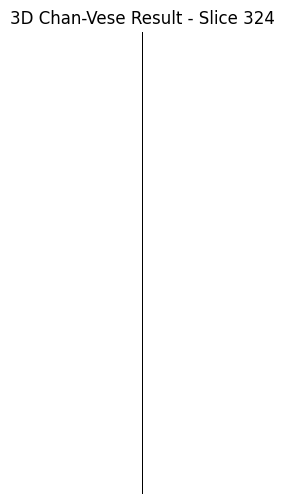

In [9]:
z = volume.shape[0] // 2

plt.figure(figsize=(6, 6))
plt.imshow(volume[z], cmap="gray")
plt.contour(mask_3d[z], levels=[0.5], colors="red")
plt.title(f"3D Chan-Vese Result - Slice {z}")
plt.axis("off")
plt.show()

In [10]:
mask_uint8 = mask_3d.astype(np.uint8) * 255

imwrite("chan_vese_3d_mask.tif", mask_uint8)

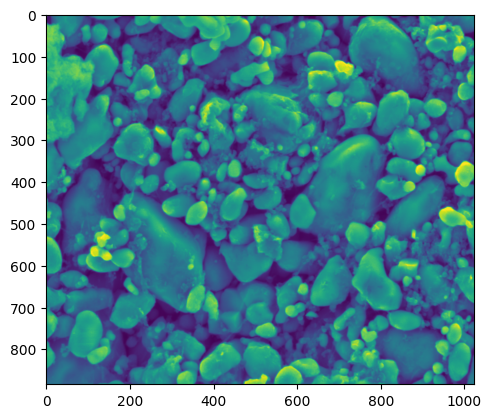

In [12]:
# -----------------------------
# 1. Load image
# -----------------------------
image = io.imread(r"sem_data/LFP_backscatter_fresh_001.tif")

# Convert to grayscale if needed
if image.ndim == 3:
    image = color.rgb2gray(image)

# Convert to float (recommended)
image = img_as_float(image)
plt.imshow(image)

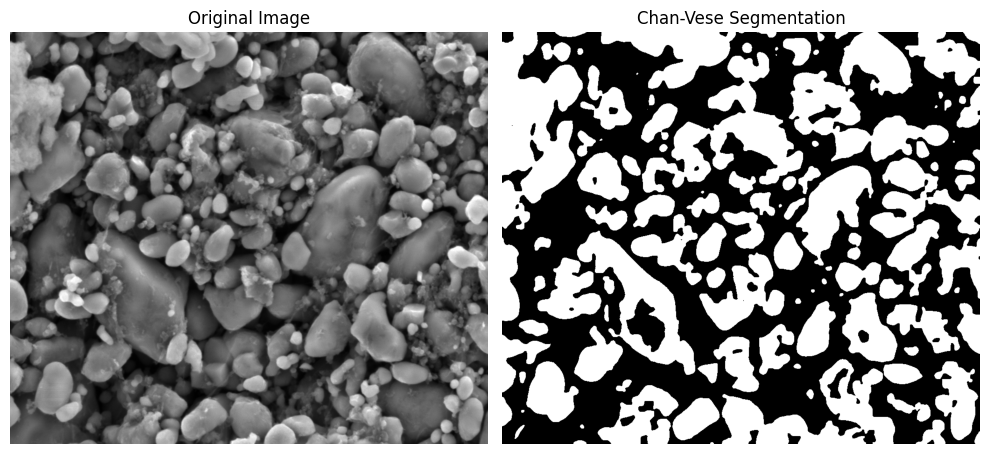

In [8]:
# 2. Run Chan-Vese segmentation
# -----------------------------
segmentation = chan_vese(
    image,
    mu=0.25,                # smoothness of contour
    lambda1=1,              # weight for inside region
    lambda2=1,              # weight for outside region
    tol=1e-3,               # convergence tolerance
    max_num_iter=500,       # maximum iterations
    dt=0.5,                 # step size
    init_level_set="checkerboard",  # initial contour
    extended_output=False
)


# -----------------------------
# 3. Visualize results
# -----------------------------
fig, axes = plt.subplots(1, 2, figsize=(10,5))

axes[0].imshow(image, cmap="gray")
axes[0].set_title("Original Image")
axes[0].axis("off")

axes[1].imshow(~segmentation, cmap="gray")
axes[1].set_title("Chan-Vese Segmentation")
axes[1].axis("off")

plt.tight_layout()
plt.show()

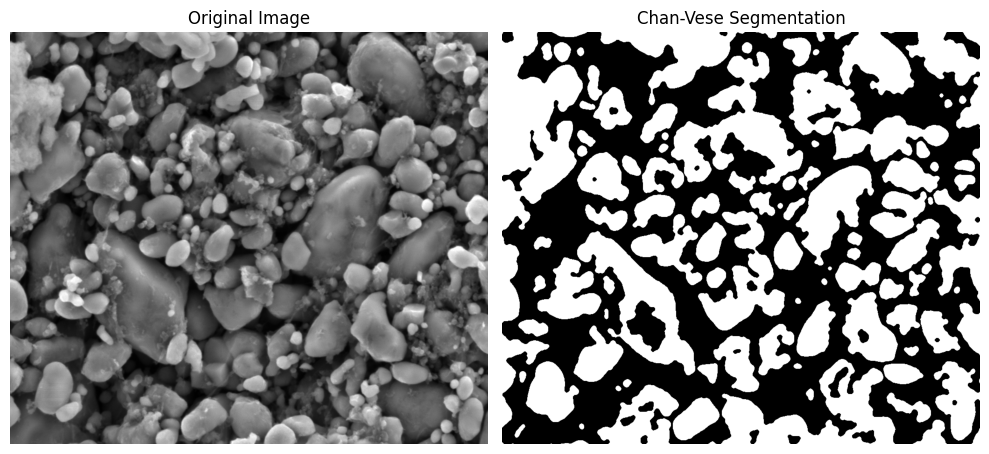

In [20]:
# 2. Run Chan-Vese segmentation
# -----------------------------
segmentation = morphological_chan_vese(
    image,
    num_iter=300,
    init_level_set="checkerboard",
    smoothing=3,
    lambda1=1,
    lambda2=1
)


# -----------------------------
# 3. Visualize results
# -----------------------------
fig, axes = plt.subplots(1, 2, figsize=(10,5))

axes[0].imshow(image, cmap="gray")
axes[0].set_title("Original Image")
axes[0].axis("off")

axes[1].imshow(~segmentation, cmap="gray")
axes[1].set_title("Chan-Vese Segmentation")
axes[1].axis("off")

plt.tight_layout()
plt.show()

In [21]:
from PIL import Image
import numpy as np

mask_uint8 = (segmentation.astype(np.uint8)) * 255
Image.fromarray(mask_uint8).save("segmented_mask.tif")

In [6]:
from ultralytics.models.sam import SAM3SemanticPredictor

# Initialize predictor with configuration
overrides = dict(
    conf=0.25,
    task="segment",
    mode="predict",
    model="sam3.pt",
    half=True,  # Use FP16 for faster inference
    save=True,
)
predictor = SAM3SemanticPredictor(overrides=overrides)

# Set image once for multiple queries
predictor.set_image("sem_data/LFP_backscatter_fresh_001.tif")

# Query with multiple text prompts
#results = predictor(text=["pores", "active particles", "carbon black and binder"])

# Works with descriptive phrases
results = predictor(text=["pores with high contrast", "particles with irregular shape"])

# Query with a single concept
#results = predictor(text=["Battery microstructure"])

Ultralytics 8.4.38  Python-3.14.3 torch-2.11.0+cu130 CUDA:0 (NVIDIA GeForce RTX 4070 Laptop GPU, 8188MiB)


c:\Users\meize\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


KeyboardInterrupt: 

In [10]:
import tifffile as tiff
from skimage.segmentation import morphological_chan_vese

# Load 3D TIFF
volume = tiff.imread("sem_data/LFP_FIB_SEM_3D_2_Gauss.tiff")

# Segment
segmented = morphological_chan_vese(
    volume,
    num_iter=100,
    init_level_set='checkerboard'
)

In [ ]:

imwrite("chan_vese_3d.tif", segmented)